In [76]:
import pandas as pd
import rdkit
import deepchem
print("Enfin prêt sur Mac !")

Enfin prêt sur Mac !


In [77]:
!pip install optuna

  Using cached markupsafe-3.0.3-cp310-cp310-macosx_11_0_arm64.whl.metadata (2.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 5.4 MB/s  0:00:00 eta 0:00:01
Using cached markupsafe-3.0.3-cp310-cp310-macosx_11_0_arm64.whl (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [optuna]2m6/7 [optuna]]my]


In [2]:
import pandas as pd

# Comme le fichier est dans le même dossier que ton notebook,
# il suffit d'écrire son nom exact.
df = pd.read_csv('df_elec.csv')

print(f"✅ Succès ! {len(df)} molécules chargées.")
display(df.head())

✅ Succès ! 534119 molécules chargées.


,Unnamed: 0,smiles,elec_sites,elec_names,MAA_values,elec_GCS_3_cm5,Set
0,0,NOCc1cccc(I)c1,3,double_bond,90.348433,"[-0.01706, 0.12057, -0.11146, -0.08969, 0.0, -...",Train_fold5
1,1,NOCc1cccc(I)c1,4,double_bond,94.924314,"[-0.08969, -0.01706, -0.08484, 0.09939, 0.0, 0...",Train_fold2
2,2,NOCc1cccc(I)c1,5,double_bond,91.330269,"[-0.08484, -0.10499, -0.08969, 0.09122, 0.0, 0...",Train_fold3
3,3,NOCc1cccc(I)c1,6,double_bond,102.683928,"[-0.10499, 0.01492, -0.08484, 0.08707, 0.0, 0....",Train_fold1
4,4,NOCc1cccc(I)c1,7,double_bond,276.204538,"[0.01492, 0.00479, -0.11146, -0.10499, 0.0, 0....",Train_fold3


In [67]:
import pandas as pd
import numpy as np
from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator
from tqdm.auto import tqdm
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split

# --- 1. CHARGEMENT ET NETTOYAGE DES DONNÉES ---
path_elec = 'df_elec.csv'
df_elec = pd.read_csv(path_elec)

# On garde uniquement le meilleur site par SMILES et on vire les colonnes inutiles
# L'utilisation de .copy() évite les messages d'avertissement de Pandas
df_final = (df_elec
            .sort_values('MAA_values', ascending=False)
            .drop_duplicates('smiles')
            .drop(columns=['elec_GCS_3_cm5', 'elec_sites', 'Set', 'elec_names'], errors='ignore')
            .copy())

# Suppression de la colonne d'index si elle existe
if 'Unnamed: 0' in df_final.columns:
    df_final = df_final.drop(columns=['Unnamed: 0'])

print(f"✅ Dataset prêt : {len(df_final)} électrophiles uniques.")

# 1. Création du générateur (On le sort de la boucle pour booster la vitesse)
mfpgen_binary = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# --- 2. GÉNÉRATION DES MORGAN FINGERPRINTS ---
def smiles_to_binary_fp(smiles):
    if not isinstance(smiles, str):
        return np.zeros(2048, dtype=np.int8) # Attention, on passe en int32 pour pouvoir compter au-delà de 1 !
    
    mol = Chem.MolFromSmiles(smiles)
    
    if mol:
        return mfpgen_binary.GetFingerprintAsNumPy(mol)
    else:
        return np.zeros(2048, dtype=np.int8)

print("🧪 Calcul des Morgan Fingerprints (2048 bits)...")
features_raw = np.array([smiles_to_binary_fp(s) for s in tqdm(df_final['smiles'])])

# --- 3. FILTRAGE DES COLONNES VIDES (VarianceThreshold) ---
# On retire les colonnes qui ne changent jamais (vitesse boostée pour les modèles)
selector = VarianceThreshold(threshold=0.0)
features_clean = selector.fit_transform(features_raw)

print(f"📉 Filtrage terminé : {features_raw.shape[1]} -> {features_clean.shape[1]} colonnes utiles.")

# --- 4. LE SPLIT FINAL (Méthode Standard) ---
X = features_clean
y = df_final['MAA_values'].values

# Le random_state=42 garantit que ton mélange est toujours le même si tu relances
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

# --- 5. VÉRIFICATION FINALE DES MOYENNES ---
print("\n🎯 RÉSUMÉ DU PRÉ-TRAITEMENT :")
print(f"• X_train : {X_train.shape[0]} molécules")
print(f"• X_test  : {X_test.shape[0]} molécules")
print(f"• Moyenne Train : {y_train.mean():.2f}")
print(f"• Moyenne Test  : {y_test.mean():.2f}")
print("\n🚀 Prêt pour l'entraînement et l'optimisation !")

✅ Dataset prêt : 47440 électrophiles uniques.
🧪 Calcul des Morgan Fingerprints (2048 bits)...






























































































100%|██████████| 47440/47440 [00:04<00:00, 10239.35it/s]


📉 Filtrage terminé : 2048 -> 2048 colonnes utiles.

🎯 RÉSUMÉ DU PRÉ-TRAITEMENT :
• X_train : 37952 molécules
• X_test  : 9488 molécules
• Moyenne Train : 179.82
• Moyenne Test  : 179.46

🚀 Prêt pour l'entraînement et l'optimisation !


In [50]:
import xgboost as xgb
# random forest regressor, and the default criterion is mean squared error (MSE)
from sklearn.ensemble import RandomForestRegressor
ranf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, max_features='sqrt', n_jobs=6, min_samples_leaf=5)
# XGBoost regressor
from xgboost import XGBRegressor
xgb_reg = XGBRegressor(
    n_estimators=100,
    max_depth=6,           # Profondeur modérée pour éviter d'apprendre par cœur
    learning_rate=0.1,     # Vitesse d'apprentissage standard
    subsample=0.8,         # Utilise 80% des molécules à chaque étape (ajoute du hasard bénéfique)
    colsample_bytree=0.8,  # Utilise 80% des colonnes (évite de se focaliser sur un seul bit)
    n_jobs=6,             # À fond sur tous les cœurs
    random_state=42
)


In [51]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

all_results = []

def train_test_model(model, X_train, y_train, X_test, y_test, name="Modèle"):
    with tqdm(total=3, desc=f"⏳ {name}") as pbar:
        
        # 1. Entraînement
        model.fit(X_train, y_train)
        pbar.update(1)
        
        # 2. Prédiction
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        pbar.update(1)
        
        # 3. Calcul des scores
        # RMSE Bruts
        train_rmse = mean_squared_error(y_train, y_pred_train) ** 0.5
        test_rmse = mean_squared_error(y_test, y_pred_test) ** 0.5
        
        # R2 Score
        train_r2 = r2_score(y_train, y_pred_train)
        test_r2 = r2_score(y_test, y_pred_test)
        
        # RMSE Relatif (en % par rapport à la moyenne du set de test)
        # On utilise la moyenne du Test pour avoir un point de comparaison fixe
        mean_val = np.mean(y_test)
        rel_rmse = (test_rmse / mean_val) * 100 if mean_val != 0 else 0
        
        pbar.update(1)
        pbar.set_description(f"✨ {name} Terminé")

    # On ajoute les scores au tableau final
    all_results.append({
        "Modèle": name,
        "RMSE Test": round(test_rmse, 2),
        "R² Test": round(test_r2, 3),
        "Rel. RMSE %": f"{round(rel_rmse, 1)}%",
        "RMSE Train": round(train_rmse, 2),
        "R² Train": round(train_r2, 3)
    })

    return y_pred_test



In [52]:
# On récupère les prédictions dans des variables dédiées
preds_rf = train_test_model(ranf_reg, X_train, y_train, X_test, y_test, name="Random Forest")


✨ Random Forest Terminé: 100%|██████████| 3/3 [00:01<00:00,  1.56it/s]


✨ XGBoost Terminé: 100%|██████████| 3/3 [00:01<00:00,  1.50it/s]


📊 RÉCAPITULATIF DES PERFORMANCES :


,Modèle,RMSE Test,R² Test,Rel. RMSE %,RMSE Train,R² Train
0,Random Forest,46.49,0.331,25.9%,45.84,0.349
1,XGBoost,33.20,0.659,18.5%,30.66,0.709


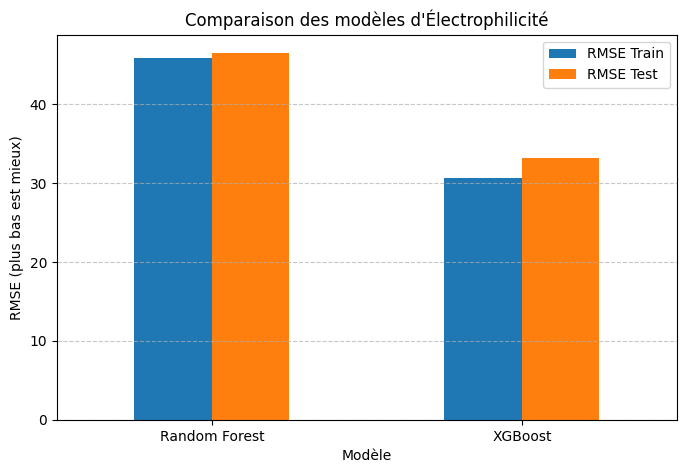

In [53]:
import matplotlib.pyplot as plt

# On récupère les prédictions dans des variables dédiées
preds_xgb = train_test_model(xgb_reg, X_train, y_train, X_test, y_test, name="XGBoost")

# --- AFFICHAGE FINAL ---

df_results = pd.DataFrame(all_results)
print("\n📊 RÉCAPITULATIF DES PERFORMANCES :")
display(df_results)

# Graphique de comparaison
df_results.set_index('Modèle')[['RMSE Train', 'RMSE Test']].plot(kind='bar', figsize=(8, 5))
plt.ylabel("RMSE (plus bas est mieux)")
plt.title("Comparaison des modèles d'Électrophilicité")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

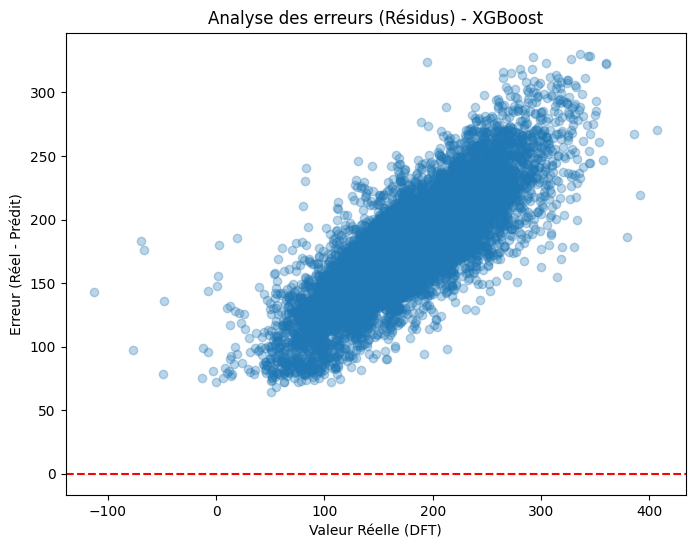

In [ ]:
# Exemple pour analyser le XGBoost
plt.figure(figsize=(8, 6))
plt.scatter(y_test, preds_xgb, alpha=0.3)
plt.axline((0, 0), slope=1, color='r', linestyle='--')
plt.title("Analyse des Prédictions - XGBoost")
plt.xlabel("Valeur Réelle (DFT)")
plt.ylabel("Valeur Prédite (XGBoost)")
plt.show()

📊 RÉCAPITULATIF COMPLET DES PERFORMANCES :


,Modèle,RMSE Test,R² Test,Rel. RMSE %,RMSE Train,R² Train
1,XGBoost,33.20,0.659,18.5%,30.66,0.709
0,Random Forest,46.85,0.321,26.1%,46.15,0.340


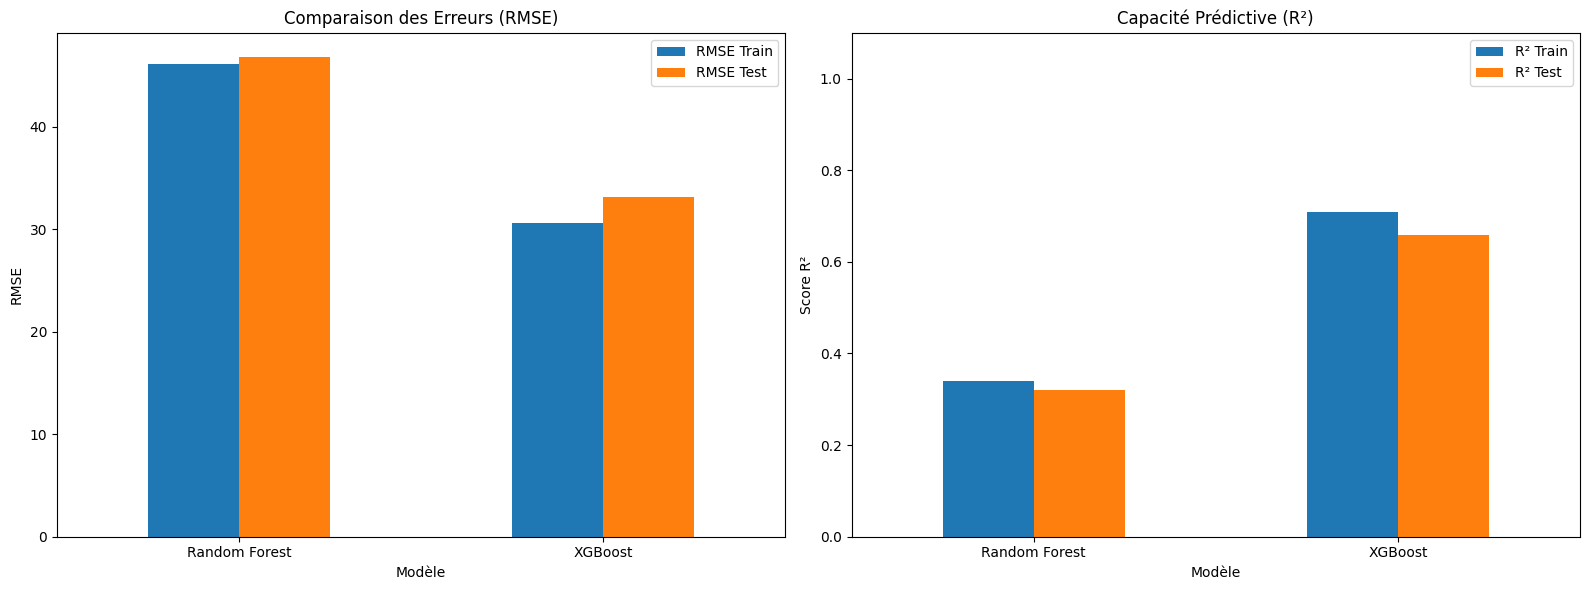

In [42]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Génération du DataFrame final à partir des résultats accumulés
df_final_results = pd.DataFrame(all_results)

# 2. Affichage du tableau propre
print("📊 RÉCAPITULATIF COMPLET DES PERFORMANCES :")
# On trie par RMSE Test pour voir le meilleur modèle en haut
display(df_final_results.sort_values(by='RMSE Test'))

# 3. Graphique comparatif Multi-Indicateurs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graphique des RMSE (Plus bas est mieux)
df_final_results.set_index('Modèle')[['RMSE Train', 'RMSE Test']].plot(kind='bar', ax=ax1)
ax1.set_ylabel("RMSE")
ax1.set_title("Comparaison des Erreurs (RMSE)")
ax1.tick_params(axis='x', rotation=0)

# Graphique des R² (Plus haut est mieux, max 1.0)
df_final_results.set_index('Modèle')[['R² Train', 'R² Test']].plot(kind='bar', ax=ax2)
ax2.set_ylabel("Score R²")
ax2.set_ylim(0, 1.1) # Pour mieux voir la proximité de 1.0
ax2.set_title("Capacité Prédictive (R²)")
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
##PREMIÈRE OPTIMISATION (AVEC GRIDSEARCH)##


from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

# 1. On règle les paramètres du XGBoost (les boutons à tourner)
param_grid_xgb = {
    'n_estimators': [100, 200, 300], # Nombre d'arbres
    'max_depth': [3, 5, 7],          # Profondeur des arbres
    'learning_rate': [0.05, 0.1]     # Vitesse d'apprentissage
}

# 2. La grille de recherche (avec tes 6 cœurs !)
grid_xgb = GridSearchCV(
    XGBRegressor(random_state=42), 
    param_grid_xgb, 
    cv=5, 
    n_jobs=6, # On utilise tes 6 cœurs
    verbose=2,
    scoring='neg_mean_squared_error'
)

print("🚀 Lancement de l'optimisation XGBoost sur 6 cœurs...")
grid_xgb.fit(X_train, y_train)

# 3. Récupération des résultats
print(f"\n✅ Meilleurs paramètres trouvés : {grid_xgb.best_params_}")

# On peut tester directement le meilleur modèle
best_xgb = grid_xgb.best_estimator_
preds_best_xgb = train_test_model(best_xgb, X_train, y_train, X_test, y_test, name="XGBoost Optimisé")

🚀 Lancement de l'optimisation XGBoost sur 6 cœurs...
Fitting 5 folds for each of 18 candidates, totalling 90 fits


[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=100; total time=   6.3s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=100; total time=   6.3s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=100; total time=   6.4s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=100; total time=   6.4s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=100; total time=   6.4s


KeyboardInterrupt: 

In [ ]:

import xgboost as xgb
# random forest regressor, and the default criterion is mean squared error (MSE)
from sklearn.ensemble import RandomForestRegressor
ranf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, max_features='sqrt', n_jobs=6, min_samples_leaf=5)
# XGBoost regressor
from xgboost import XGBRegressor
xgb_reg = XGBRegressor(
    n_estimators=100,
    max_depth=6,           # Profondeur modérée pour éviter d'apprendre par cœur
    learning_rate=0.1,     # Vitesse d'apprentissage standard
    subsample=0.8,         # Utilise 80% des molécules à chaque étape (ajoute du hasard bénéfique)
    colsample_bytree=0.8,  # Utilise 80% des colonnes (évite de se focaliser sur un seul bit)
    n_jobs=6,             # À fond sur tous les cœurs
    random_state=42
)
xgb_reg2 = XGBRegressor(
    n_estimators=300,
    max_depth=7,           # Profondeur modérée pour éviter d'apprendre par cœur
    learning_rate=0.1,     # Vitesse d'apprentissage standard
    subsample=0.8,         # Utilise 80% des molécules à chaque étape (ajoute du hasard bénéfique)
    colsample_bytree=0.8,  # Utilise 80% des colonnes (évite de se focaliser sur un seul bit)
    n_jobs=6,             # À fond sur tous les cœurs
    random_state=42)

In [70]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

all_results = []

def train_test_model(model, X_train, y_train, X_test, y_test, name="Modèle"):
    with tqdm(total=3, desc=f"⏳ {name}") as pbar:
        
        # 1. Entraînement
        model.fit(X_train, y_train)
        pbar.update(1)
        
        # 2. Prédiction
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        pbar.update(1)
        
        # 3. Calcul des scores
        # RMSE Bruts
        train_rmse = mean_squared_error(y_train, y_pred_train) ** 0.5
        test_rmse = mean_squared_error(y_test, y_pred_test) ** 0.5
        
        # R2 Score
        train_r2 = r2_score(y_train, y_pred_train)
        test_r2 = r2_score(y_test, y_pred_test)
        
        # RMSE Relatif (en % par rapport à la moyenne du set de test)
        # On utilise la moyenne du Test pour avoir un point de comparaison fixe
        mean_val = np.mean(y_test)
        rel_rmse = (test_rmse / mean_val) * 100 if mean_val != 0 else 0
        
        pbar.update(1)
        pbar.set_description(f"✨ {name} Terminé")

    # On ajoute les scores au tableau final
    all_results.append({
        "Modèle": name,
        "RMSE Test": round(test_rmse, 2),
        "R² Test": round(test_r2, 3),
        "Rel. RMSE %": f"{round(rel_rmse, 1)}%",
        "RMSE Train": round(train_rmse, 2),
        "R² Train": round(train_r2, 3)
    })

    return y_pred_test

In [71]:
# On récupère les prédictions dans des variables dédiées
preds_rf = train_test_model(ranf_reg, X_train, y_train, X_test, y_test, name="Random Forest")




  0%|          | 0/47440 [01:09<?, ?it/s]






✨ Random Forest Terminé: 100%|██████████| 3/3 [00:01<00:00,  1.57it/s]





✨ XGBoost Terminé: 100%|██████████| 3/3 [00:02<00:00,  1.48it/s]



✨ XGBoost2 Terminé: 100%|██████████| 3/3 [00:04<00:00,  1.57s/it]


📊 RÉCAPITULATIF DES PERFORMANCES :


,Modèle,RMSE Test,R² Test,Rel. RMSE %,RMSE Train,R² Train
0,Random Forest,46.92,0.319,26.1%,46.32,0.335
1,XGBoost,33.20,0.659,18.5%,30.66,0.709
2,XGBoost2,30.20,0.718,16.8%,23.12,0.834


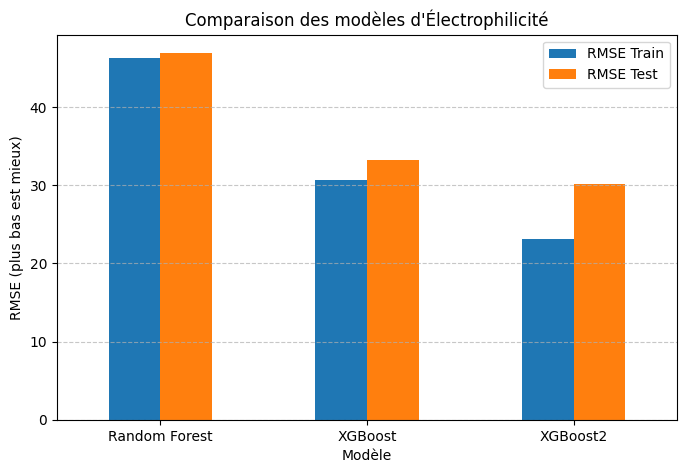

In [ ]:
import matplotlib.pyplot as plt

# On récupère les prédictions dans des variables dédiées
preds_xgb = train_test_model(xgb_reg, X_train, y_train, X_test, y_test, name="XGBoost")

preds_xgb2 = train_test_model(xgb_reg2, X_train, y_train, X_test, y_test, name="XGBoost2")
# --- AFFICHAGE FINAL ---

df_results = pd.DataFrame(all_results)
print("\n📊 RÉCAPITULATIF DES PERFORMANCES :")
display(df_results)

# Graphique de comparaison
df_results.set_index('Modèle')[['RMSE Train', 'RMSE Test']].plot(kind='bar', figsize=(8, 5))
plt.ylabel("RMSE (plus bas est mieux)")
plt.title("Comparaison des modèles d'Électrophilicité")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

📊 RÉCAPITULATIF COMPLET DES PERFORMANCES :


,Modèle,RMSE Test,R² Test,Rel. RMSE %,RMSE Train,R² Train
2,XGBoost2,30.20,0.718,16.8%,23.12,0.834
1,XGBoost,33.20,0.659,18.5%,30.66,0.709
0,Random Forest,46.92,0.319,26.1%,46.32,0.335


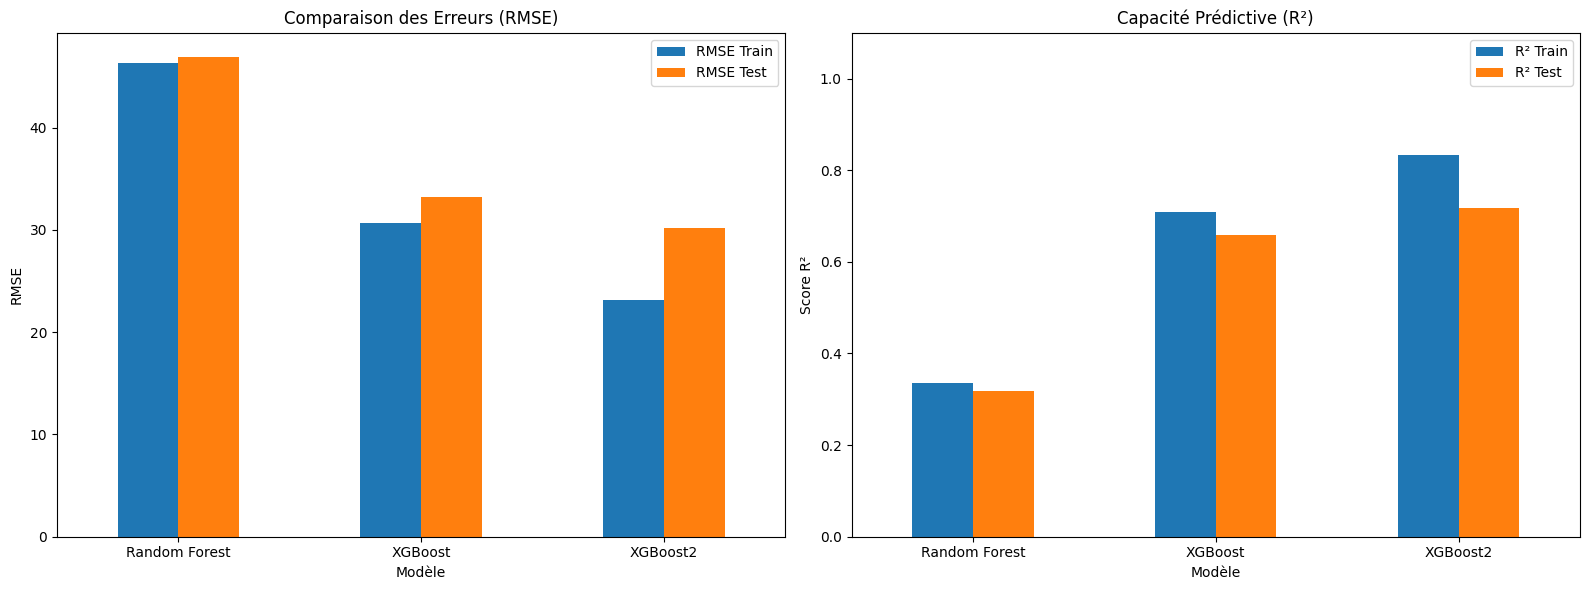

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Génération du DataFrame final à partir des résultats accumulés
df_final_results = pd.DataFrame(all_results)

# 2. Affichage du tableau propre
print("📊 RÉCAPITULATIF COMPLET DES PERFORMANCES :")
# On trie par RMSE Test pour voir le meilleur modèle en haut
display(df_final_results.sort_values(by='RMSE Test'))

# 3. Graphique comparatif Multi-Indicateurs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graphique des RMSE (Plus bas est mieux)
df_final_results.set_index('Modèle')[['RMSE Train', 'RMSE Test']].plot(kind='bar', ax=ax1)
ax1.set_ylabel("RMSE")
ax1.set_title("Comparaison des Erreurs (RMSE)")
ax1.tick_params(axis='x', rotation=0)

# Graphique des R² (Plus haut est mieux, max 1.0)
df_final_results.set_index('Modèle')[['R² Train', 'R² Test']].plot(kind='bar', ax=ax2)
ax2.set_ylabel("Score R²")
ax2.set_ylim(0, 1.1) # Pour mieux voir la proximité de 1.0
ax2.set_title("Capacité Prédictive (R²)")
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
##OPTIMISATION BAYÉSIENNE AVEC OPTUNA##

import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore') # Pour cacher les petits avertissements

print("🧠 Début de l'optimisation Bayésienne avec Optuna...")

# 1. On définit la mission d'Optuna (trouver les meilleurs réglages)
def objective(trial):
    # Optuna va tester ces "boutons" intelligemment
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1500), # On l'autorise à faire beaucoup d'arbres
        'max_depth': trial.suggest_int('max_depth', 3, 9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'random_state': 42,
        'n_jobs': 6, # Tes 6 cœurs
        'early_stopping_rounds': 20 # S'il ne s'améliore pas pendant 20 arbres, il coupe !
    }

    # On crée le modèle avec les paramètres du test actuel
    model = XGBRegressor(**param)

    # On entraîne (et on lui donne X_test pour qu'il surveille son propre overfit)
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False # On le fait taire pour ne pas polluer l'écran
    )

    # On évalue son erreur
    preds = model.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse) # On calcule la racine carrée manuellement
    
    return rmse # Le but d'Optuna est de minimiser ce score

# 2. On lance l'étude (20 tentatives intelligentes)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

# 3. Affichage du grand gagnant
print("\n✅ OPTIMISATION TERMINÉE !")
print(f"🏆 Meilleur RMSE trouvé : {study.best_value:.2f}")
print("Meilleurs paramètres :")
for key, value in study.best_params.items():
    print(f"  - {key}: {value}")

[I 2026-04-21 15:55:24,483] A new study created in memory with name: no-name-c9835f3c-7c65-4826-a87c-339e72fe14d0


🧠 Début de l'optimisation Bayésienne avec Optuna...


[I 2026-04-21 15:55:36,803] Trial 0 finished with value: 31.27787050243295 and parameters: {'n_estimators': 621, 'max_depth': 5, 'learning_rate': 0.05540021849651809, 'subsample': 0.7687296326499806}. Best is trial 0 with value: 31.27787050243295.
[I 2026-04-21 15:55:56,955] Trial 1 finished with value: 33.08665152327573 and parameters: {'n_estimators': 962, 'max_depth': 5, 'learning_rate': 0.015743392241297532, 'subsample': 0.6745103002455677}. Best is trial 0 with value: 31.27787050243295.
[I 2026-04-21 15:56:18,261] Trial 2 finished with value: 28.4462713150217 and parameters: {'n_estimators': 917, 'max_depth': 9, 'learning_rate': 0.05683105748846327, 'subsample': 0.6549000012600802}. Best is trial 2 with value: 28.4462713150217.
[I 2026-04-21 15:56:40,802] Trial 3 finished with value: 30.46766897959972 and parameters: {'n_estimators': 1048, 'max_depth': 6, 'learning_rate': 0.030197157460474182, 'subsample': 0.8635982288162477}. Best is trial 2 with value: 28.4462713150217.
[I 2026-


✅ OPTIMISATION TERMINÉE !
🏆 Meilleur RMSE trouvé : 28.07
Meilleurs paramètres :
  - n_estimators: 1480
  - max_depth: 9
  - learning_rate: 0.06009401524691059
  - subsample: 0.647226249869362


In [80]:

import xgboost as xgb
# random forest regressor, and the default criterion is mean squared error (MSE)
from sklearn.ensemble import RandomForestRegressor
ranf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, max_features='sqrt', n_jobs=6, min_samples_leaf=5)
# XGBoost regressor
from xgboost import XGBRegressor
xgb_reg = XGBRegressor(
    n_estimators=100,
    max_depth=6,           # Profondeur modérée pour éviter d'apprendre par cœur
    learning_rate=0.1,     # Vitesse d'apprentissage standard
    subsample=0.8,         # Utilise 80% des molécules à chaque étape (ajoute du hasard bénéfique)
    colsample_bytree=0.8,  # Utilise 80% des colonnes (évite de se focaliser sur un seul bit)
    n_jobs=6,             # À fond sur tous les cœurs
    random_state=42
)
xgb_reg_GridSearchCV_ = XGBRegressor(
    n_estimators=300,
    max_depth=7,           # Profondeur modérée pour éviter d'apprendre par cœur
    learning_rate=0.1,     # Vitesse d'apprentissage standard
    subsample=0.8,         # Utilise 80% des molécules à chaque étape (ajoute du hasard bénéfique)
    colsample_bytree=0.8,  # Utilise 80% des colonnes (évite de se focaliser sur un seul bit)
    n_jobs=6,             # À fond sur tous les cœurs
    random_state=42)

xgb_reg_OPTUNA = XGBRegressor(
    n_estimators=1480,
    max_depth=9,           # Profondeur modérée pour éviter d'apprendre par cœur
    learning_rate=0.06009401524691059,     # Vitesse d'apprentissage standard
    subsample=0.647226249869362,         # Utilise 80% des molécules à chaque étape (ajoute du hasard bénéfique)
    colsample_bytree=0.8,  # Utilise 80% des colonnes (évite de se focaliser sur un seul bit)
    n_jobs=6,             # À fond sur tous les cœurs
    random_state=42)


In [84]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

all_results = []

def train_test_model(model, X_train, y_train, X_test, y_test, name="Modèle"):
    with tqdm(total=3, desc=f"⏳ {name}") as pbar:
        
        # 1. Entraînement
        model.fit(X_train, y_train)
        pbar.update(1)
        
        # 2. Prédiction
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        pbar.update(1)
        
        # 3. Calcul des scores
        # RMSE Bruts
        train_rmse = mean_squared_error(y_train, y_pred_train) ** 0.5
        test_rmse = mean_squared_error(y_test, y_pred_test) ** 0.5
        
        # R2 Score
        train_r2 = r2_score(y_train, y_pred_train)
        test_r2 = r2_score(y_test, y_pred_test)
        
        # RMSE Relatif (en % par rapport à la moyenne du set de test)
        # On utilise la moyenne du Test pour avoir un point de comparaison fixe
        mean_val = np.mean(y_test)
        rel_rmse = (test_rmse / mean_val) * 100 if mean_val != 0 else 0
        
        pbar.update(1)
        pbar.set_description(f"✨ {name} Terminé")

    # On ajoute les scores au tableau final
    all_results.append({
        "Modèle": name,
        "RMSE Test": round(test_rmse, 2),
        "R² Test": round(test_r2, 3),
        "Rel. RMSE %": f"{round(rel_rmse, 1)}%",
        "RMSE Train": round(train_rmse, 2),
        "R² Train": round(train_r2, 3)
    })

    return y_pred_test

✨ XGBoost OPTUNA Terminé: 100%|██████████| 3/3 [00:23<00:00,  7.71s/it]


📊 RÉCAPITULATIF DES PERFORMANCES :


,Modèle,RMSE Test,R² Test,Rel. RMSE %,RMSE Train,R² Train
0,Random Forest,46.56,0.329,25.9%,45.93,0.346
1,XGBoost,33.20,0.659,18.5%,30.66,0.709
2,XGBoost GridSearchCV,30.20,0.718,16.8%,23.12,0.834
3,XGBoost OPTUNA,27.99,0.758,15.6%,10.97,0.963


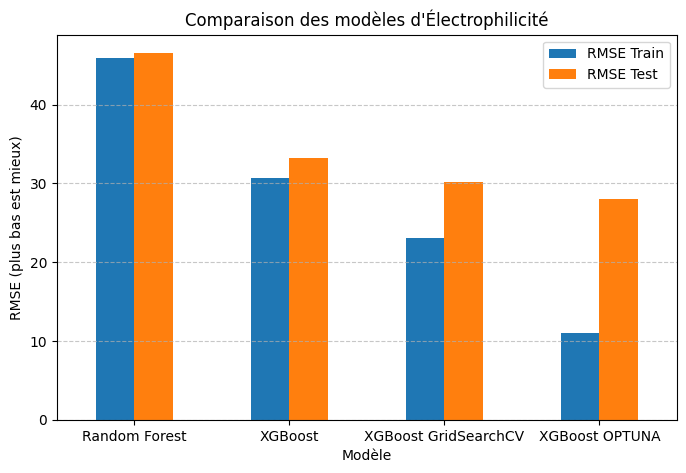

In [85]:

import matplotlib.pyplot as plt
# On récupère les prédictions dans des variables dédiées
preds_rf = train_test_model(ranf_reg, X_train, y_train, X_test, y_test, name="Random Forest")

preds_xgb = train_test_model(xgb_reg, X_train, y_train, X_test, y_test, name="XGBoost")

preds_xgb_GridSearchCV = train_test_model(xgb_reg_GridSearchCV_, X_train, y_train, X_test, y_test, name="XGBoost GridSearchCV")

preds_xgb_OPTUNA = train_test_model(xgb_reg_OPTUNA, X_train, y_train, X_test, y_test, name="XGBoost OPTUNA")  
  
# --- AFFICHAGE FINAL ---

df_results = pd.DataFrame(all_results)
print("\n📊 RÉCAPITULATIF DES PERFORMANCES :")
display(df_results)

# Graphique de comparaison
df_results.set_index('Modèle')[['RMSE Train', 'RMSE Test']].plot(kind='bar', figsize=(8, 5))
plt.ylabel("RMSE (plus bas est mieux)")
plt.title("Comparaison des modèles d'Électrophilicité")
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

📊 RÉCAPITULATIF COMPLET DES PERFORMANCES :


,Modèle,RMSE Test,R² Test,Rel. RMSE %,RMSE Train,R² Train
3,XGBoost OPTUNA,27.99,0.758,15.6%,10.97,0.963
2,XGBoost GridSearchCV,30.20,0.718,16.8%,23.12,0.834
1,XGBoost,33.20,0.659,18.5%,30.66,0.709
0,Random Forest,46.56,0.329,25.9%,45.93,0.346


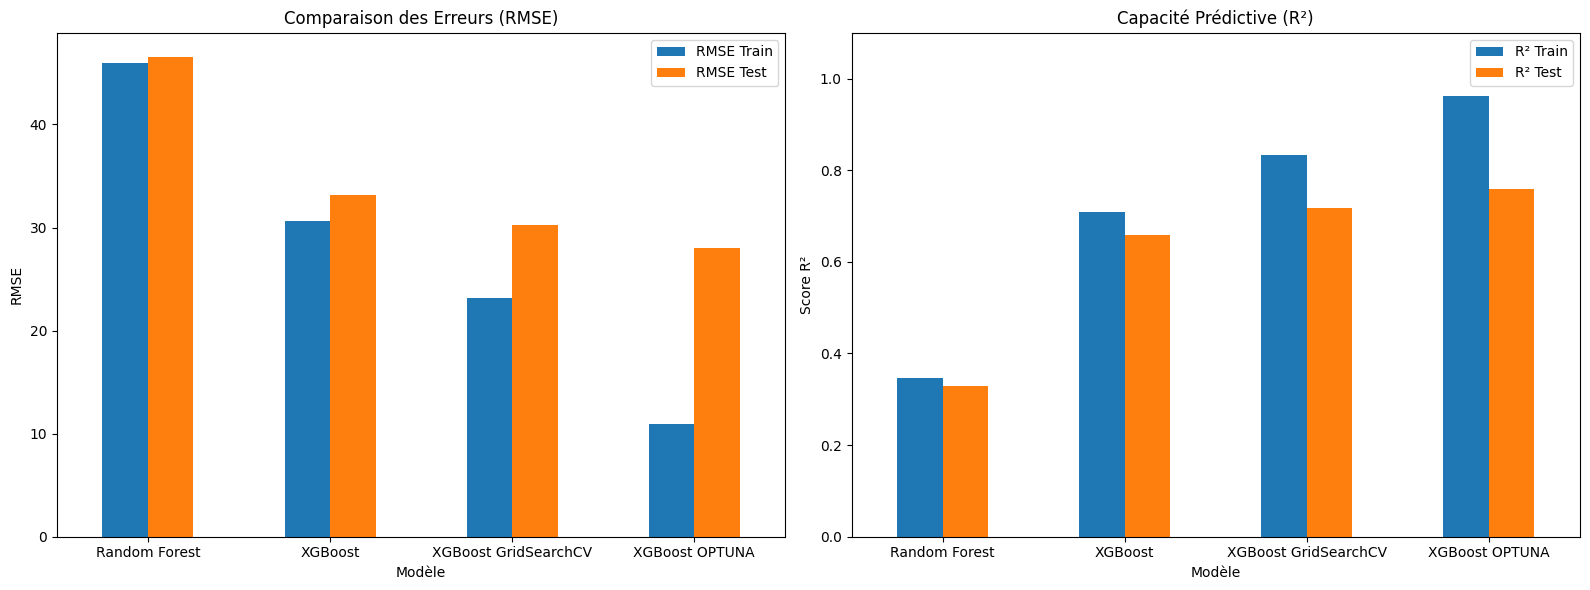

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Génération du DataFrame final à partir des résultats accumulés
df_final_results = pd.DataFrame(all_results)

# 2. Affichage du tableau propre
print("📊 RÉCAPITULATIF COMPLET DES PERFORMANCES :")
# On trie par RMSE Test pour voir le meilleur modèle en haut
display(df_final_results.sort_values(by='RMSE Test'))

# 3. Graphique comparatif Multi-Indicateurs
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Graphique des RMSE (Plus bas est mieux)
df_final_results.set_index('Modèle')[['RMSE Train', 'RMSE Test']].plot(kind='bar', ax=ax1)
ax1.set_ylabel("RMSE")
ax1.set_title("Comparaison des Erreurs (RMSE)")
ax1.tick_params(axis='x', rotation=0)

# Graphique des R² (Plus haut est mieux, max 1.0)
df_final_results.set_index('Modèle')[['R² Train', 'R² Test']].plot(kind='bar', ax=ax2)
ax2.set_ylabel("Score R²")
ax2.set_ylim(0, 1.1) # Pour mieux voir la proximité de 1.0
ax2.set_title("Capacité Prédictive (R²)")
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()